In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv('popular-languages.csv')
df.head()

,language,: average_salary
0,Python,"$114,383"
1,Java,"$101,013"
2,R,"$92,037"
3,Javascript,"$110,981"
4,Swift,"$130,801"


In [45]:
df.value_counts()

language    : average_salary
C#          $88,726             1
C++         $113,865            1
Go          $94,082             1
Java        $101,013            1
Javascript  $110,981            1
PHP         $84,727             1
Python      $114,383            1
R           $92,037             1
SQL         $84,793             1
Swift       $130,801            1
Name: count, dtype: int64

In [47]:
# Remove $ and , then convert to numeric
df['average_salary'] = df[': average_salary'].str.replace('[$,]', '', regex=True).astype(float)

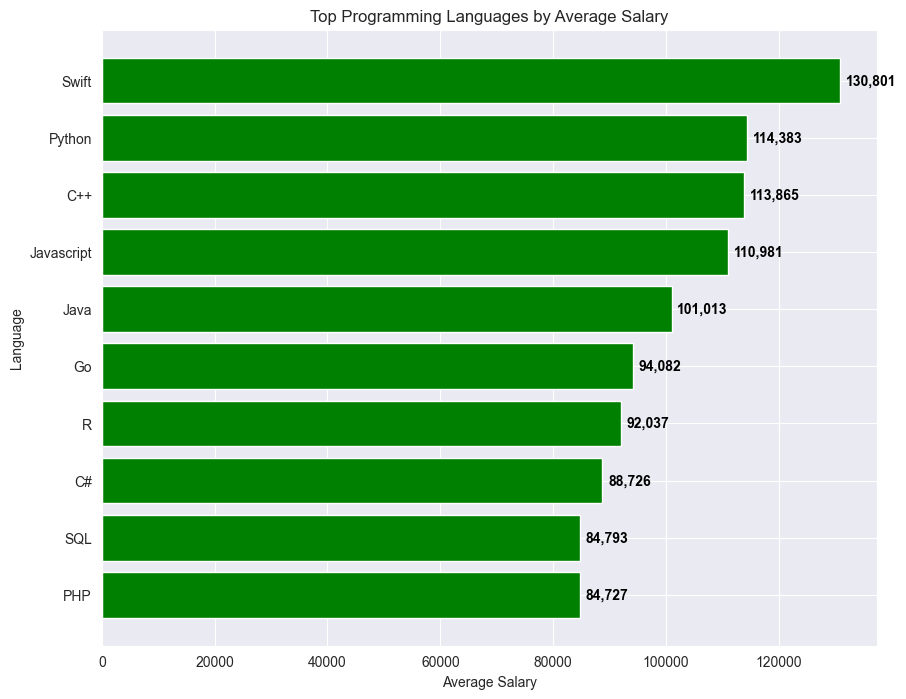

In [58]:
top_languages = df.groupby('language')['average_salary'].mean().nlargest(10).reset_index()
top_languages = top_languages.sort_values('average_salary', ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(top_languages['language'], top_languages['average_salary'], color='green')

for bar in bars:
    plt.text(bar.get_width() + 1000, 
             bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():,.0f}', 
             va='center', ha='left', color='black', fontweight='bold')

plt.xlabel('Average Salary')
plt.ylabel('Language')
plt.title('Top Programming Languages by Average Salary')
plt.show()